# LaLonde real-data validation

This notebook provides the complete real-data analysis comparing our
target-risk adjustment with the double-ridge estimators of
\citet{brunssmith2025augmented}. The observational application is kept
separate from experiments with revealed scoring outcomes. We report both
favorable and unfavorable regimes and retain the numerical and leakage audits
needed for reproduction.

## Implementation

The estimator, the risk formulas and the comparison methods live in the shared
`rcb` package, which every study imports. This study's own code -- the LaLonde
data construction, the validation protocol, the chi-square overlap design and
the paper tables -- lives in `experiments/lalonde/`; see its README. This
notebook only reads `results/lalonde/` and draws the figures.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CODE = Path.cwd()
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

from rcb import paths
from experiments.lalonde import experiment as E

STUDY = "lalonde"
OUT = paths.results(STUDY, create=False)
FIGURES = paths.figures(STUDY)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

LABEL = {
    "Pure weighting: uniform": "Weighting: uniform",
    "Pure weighting: entropy": "Weighting: regularized entropy",
    "Pure weighting: l2": "Weighting: l2 (kappa=1)",
    "Double ridge: outcome CV": "Double ridge: outcome CV",
    "Double ridge: imbalance CV": "Double ridge: imbalance CV",
    "Double ridge: Riesz CV": "Double ridge: Riesz CV",
    "Ours: uniform base, full target": "Ours: uniform base",
    "Ours: entropy base, pilot/evaluation": "Ours: entropy base (single split)",
    "Ours: l2 base, pilot/evaluation": "Ours: l2 base (single split)",
    "ARB": "ARB",
    "Double ridge: CV outcome": "Double ridge: outcome CV",
    "Double ridge: CV imbalance": "Double ridge: imbalance CV",
    "Double ridge: CV Riesz": "Double ridge: Riesz CV",
    "Ours: tuned l2 base": "Ours: tuned l2 base",
    "Ours: uniform base": "Ours: uniform base",
}

required = [
    "r1_point_estimates.csv", "r2_observational_summary.csv",
    "r3_hidden_outcome_summary.csv", "r4_single_split_stability_summary.csv",
    "r5_placebo_summary.csv", "r6_hidden_outcome_summary.csv",
    "r7_stress_test_summary.csv", "r8_cv_boundary_summary.csv",
    "r9_chi2_overlap_summary.csv", "r9_chi2_overlap_comparisons.csv",
    "r9_chi2_overlap_design.csv", "r9_chi2_overlap_validation.json",
    "paper_validation_audit.json", "extended_validation.json",
]
missing = [name for name in required if not (OUT / name).exists()]
assert not missing, f"Missing formal artifacts: {missing}"

## 0. Full experimental pipeline

The analysis runs from the command line (next cell) and writes its tables to
`results/lalonde/`; this notebook reads those tables and draws the
chi-square overlap figure, so it runs in seconds.

In [2]:
# The analysis runs from the command line, not from here:
#
#     python -m experiments.lalonde.run            # the full sequence
#     python -m experiments.lalonde.run --smoke    # reduced, to check the chain
#
# This notebook reads what that wrote.  The cells below never recompute an
# estimate, which is why they run in seconds.


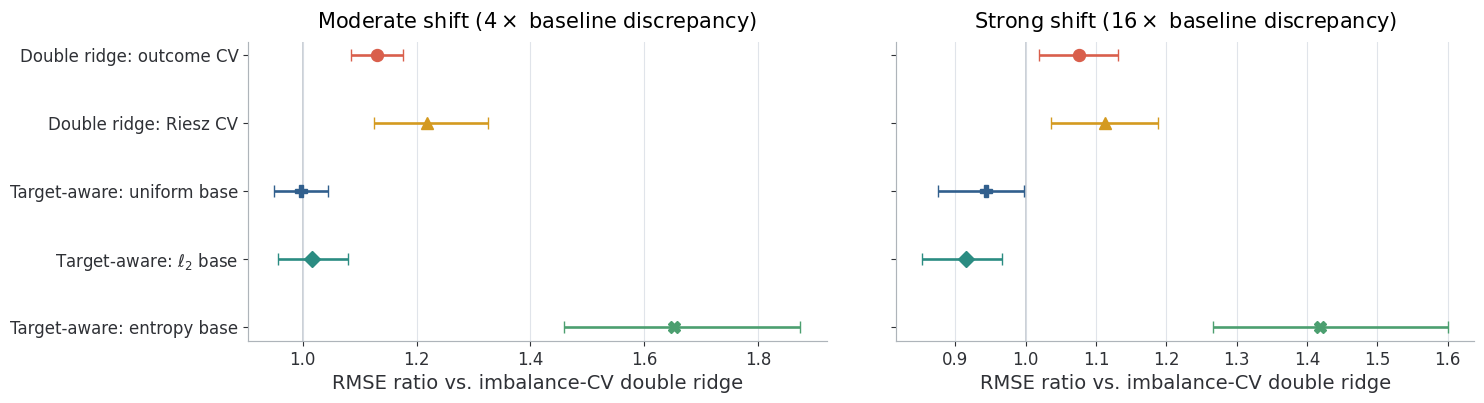

In [3]:
# Figure style and the paper's chi-square overlap figure, drawn from the summaries above.
DOUBLE = "#D95F4C"
DOUBLE_2 = "#8C6BB1"
DOUBLE_3 = "#D49A20"
OURS = "#2B8C82"
OURS_2 = "#315F8D"
NEUTRAL = "#6B7280"


METHOD_LABELS = {
    "Pure weighting: uniform": "Weighting: uniform",
    "Pure weighting: entropy": "Weighting: entropy",
    "Pure weighting: l2": r"Weighting: $\ell_2$",
    "Double ridge: outcome CV": "Double ridge: outcome CV",
    "Double ridge: imbalance CV": "Double ridge: imbalance CV",
    "Double ridge: Riesz CV": "Double ridge: Riesz CV",
    "Ours: uniform base, full target": "Ours: uniform base",
    "Ours: entropy base, pilot/evaluation": "Ours: entropy base",
    "Ours: l2 base, pilot/evaluation": r"Ours: $\ell_2$ base",
    "ARB": "ARB",
    "Double ridge: CV outcome": "Double ridge: outcome CV",
    "Double ridge: CV imbalance": "Double ridge: imbalance CV",
    "Double ridge: CV Riesz": "Double ridge: Riesz CV",
    "Ours: tuned l2 base": r"Ours: tuned $\ell_2$ base",
    "Ours: uniform base": "Ours: uniform base",
}


def style() -> None:
    E.apply_paper_plot_style()
    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 15,
        "axes.titleweight": "normal",
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    })


def chi2_overlap_figure(comparisons: pd.DataFrame) -> None:
    """Two-panel paired RMSE-ratio comparison under the chi-square overlap design, relative to imbalance-CV double ridge."""
    methods = [
        "Double ridge: outcome CV",
        "Double ridge: Riesz CV",
        "Ours: uniform base, full target",
        "Ours: l2 base, pilot/evaluation",
        "Ours: entropy base, pilot/evaluation",
    ]
    labels = [
        "Double ridge: outcome CV",
        "Double ridge: Riesz CV",
        "Target-aware: uniform base",
        r"Target-aware: $\ell_2$ base",
        "Target-aware: entropy base",
    ]
    colors = [DOUBLE, DOUBLE_3, OURS_2, OURS, "#4C9F70"]
    markers = ["o", "^", "P", "D", "X"]
    regimes = ["Moderate shift", "Strong shift"]
    regime_titles = {
        "Moderate shift": r"Moderate shift ($4\times$ baseline discrepancy)",
        "Strong shift": r"Strong shift ($16\times$ baseline discrepancy)",
    }
    y = np.arange(len(methods))[::-1]
    fig, axes = plt.subplots(1, 2, figsize=(16.8, 4.6), sharey=True)
    for ax, regime in zip(axes, regimes):
        panel = comparisons.loc[comparisons.regime == regime].set_index("method")
        ax.axvline(1.0, color="#CBD0D6", linewidth=1.4, zorder=0)
        for position, method, color, marker in zip(y, methods, colors, markers):
            row = panel.loc[method]
            ax.errorbar(
                row.rmse_ratio,
                position,
                xerr=[[row.rmse_ratio - row.rmse_ratio_lower_95],
                      [row.rmse_ratio_upper_95 - row.rmse_ratio]],
                color=color,
                marker=marker,
                markersize=8.6,
                linewidth=1.9,
                capsize=4,
                zorder=2,
            )
        ax.set_title(regime_titles[regime], fontweight="normal", pad=10)
        ax.set_xlabel("RMSE ratio vs. imbalance-CV double ridge")
        ax.grid(axis="x", color="#D9DEE5", linewidth=0.8, alpha=0.8)
        ax.grid(axis="y", visible=False)
    axes[0].set_yticks(y, labels)
    axes[0].tick_params(axis="y", labelsize=12)
    fig.subplots_adjust(
        left=0.26, right=0.99, bottom=0.21, top=0.86, wspace=0.12
    )
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / "r9_chi2_overlap_rmse.pdf", dpi=300, bbox_inches="tight",
                pad_inches=0.22, facecolor="white")
    plt.show()


style()
chi2_overlap_figure(pd.read_csv(OUT / "r9_chi2_overlap_comparisons.csv"))


## 1. Data, estimand, and protocol

We use the LaLonde job-training data \citep{lalonde1986evaluating} in the
LaLonde-171 construction of \citet{brunssmith2025augmented}. The source sample
contains 727 nonexperimental PSID controls; the target contains 185 NSW treated
units; and the fixed representation contains 171 transformed pretreatment
covariates. The estimand and estimator are

\[
\mu_0=\mathbb E\{Y(0)\mid D=1\},\qquad
\tau_{\rm ATT}=\mathbb E\{Y(1)-Y(0)\mid D=1\},\qquad
\widehat\tau_{\rm ATT}=\bar Y_1-\widehat\mu_0.
\]

Target outcomes are never supplied to routines that fit weights, nuisance
parameters, or penalties. They are revealed only after fitting, either to form
the observational ATT or to score a hidden-outcome experiment. The analyses
below are the observational application, a full-procedure paired bootstrap, a
randomized-control hidden-outcome evaluation, a pilot/evaluation split
sensitivity audit, pretreatment placebos, feature sensitivity, a known-truth
stress test, a tuning-boundary audit, and a classifier-induced chi-square
overlap stress test.

In [4]:
print(pd.read_csv(OUT / "design_samples.csv").to_string())
print(pd.read_csv(OUT / "design_representations.csv").to_string())


                      Sample    n               Outcome use
0       PSID source controls  727  fit source outcome model
1         NSW treated target  185         ATT after fitting
2  NSW-control pseudo-target  260       score after fitting
  Representation    p  Fixed common-support sample size
0          short   11                               912
1   intermediate   14                               912
2    LaLonde-171  171                               912


### Primary comparison set

The formal comparison contains nine estimators: three double-ridge tuning rules
(outcome CV, imbalance CV, and Riesz CV); our adjustment with uniform,
regularized-entropy, and \(\ell_2\) bases; and the corresponding three pure
weighting estimators. Pure
weighting means that the base weights are applied without our augmentation.
For a target-adaptive base, Algorithm 2 uses one pre-specified, approximately
equal split \((I_P,I_E)\),

\[
\widehat{\boldsymbol\gamma}
=n_0^{-1}\mathbf 1_{n_0}
+n_0^{-1}X_0^c(S_0^c+I_p)^{-1}
(\bar{\boldsymbol x}_{1,P}-\bar{\boldsymbol x}_0).
\]

The pilot subset constructs the base and the disjoint evaluation subset
minimizes \(\widehat R_n(\lambda;\widehat{\boldsymbol\gamma})\).
The \(\ell_2\) pilot penalty \(\kappa=1\) is fixed before outcome analysis. The
entropy pair uses the same pre-specified regularized entropy program; exact
unregularized entropy balance is infeasible in the 171-feature sample.
Only that one selected estimator is returned: the subset roles are not swapped
and fold-specific estimates are not averaged. The uniform base is
target-exogenous, so it uses the full target sample without splitting, as
allowed after Assumption 8.
ARB combines residual-balancing weights with a cross-validated elastic-net
outcome correction. Applying our criterion to the paper's outcome-CV ridge
weights is retained only as a same-path descriptive comparison, since that base
is outcome dependent.

## 2. Observational ATT application

The observational target does not reveal the missing \(\mu_0\). Therefore the
table describes estimates, balance, and weight stability; it does not label a
method as closer to the unknown counterfactual truth.

In [5]:
r1 = pd.read_csv(OUT / "paper_table_r1.csv")
r1 = r1.loc[r1.method != "ARB"].copy()
r1["Method"] = r1.method.map(LABEL)
r1["Penalty"] = r1.selected_lambda.map(
    lambda x: "--" if pd.isna(x) else ("infinity" if np.isinf(x) else f"{x:.4g}")
)
print(r1[[
    "Method", "muhat0", "att", "Penalty", "ess",
    "residual_imbalance_squared", "negative_weight_fraction",
]].rename(columns={
    "muhat0": "Estimated mu0", "att": "Estimated ATT",
    "ess": "ESS stability index", "residual_imbalance_squared": "Squared imbalance",
    "negative_weight_fraction": "Negative-weight fraction",
}).to_string())

                              Method  Estimated mu0  Estimated ATT Penalty  ESS stability index  Squared imbalance  Negative-weight fraction
0                 Weighting: uniform   14121.376665   -7772.233163      --           727.000000          53.398073                  0.000000
1            Weighting: l2 (kappa=1)    5437.263269     911.880233      --            79.070354           5.079900                  0.398900
2           Double ridge: outcome CV    4109.540267    2239.603235  0.1987            30.561974           0.187842                  0.451169
3         Double ridge: imbalance CV    4198.145068    2150.998434   1.041            35.405610           0.462717                  0.455296
4             Double ridge: Riesz CV    4130.377552    2218.765950  0.3724            32.419534           0.282422                  0.456671
5                 Ours: uniform base    4269.338467    2079.805036  0.0631            31.267509           0.202523                  0.442916
6       Ours:

## 3. Full-procedure paired bootstrap

Each of 500 replications independently resamples 727 source pairs and 185
target pairs. Every CV rule, design tuner, nuisance fit, base, target split, and
penalty is recomputed. These intervals are empirical bootstrap diagnostics,
not theorem-based confidence intervals.

In [6]:
r2 = pd.read_csv(OUT / "paper_table_r2.csv")
r2["Method"] = r2.method.map(LABEL)
print(r2[[
    "Method", "reps", "att_mean", "att_sd", "att_q025", "att_q975",
    "median_finite_lambda", "no_adjustment_rate",
]].rename(columns={
    "reps": "Replications", "att_mean": "ATT mean", "att_sd": "Bootstrap SD",
    "att_q025": "2.5%", "att_q975": "97.5%",
    "median_finite_lambda": "Median finite penalty",
    "no_adjustment_rate": "No-adjustment rate",
}).to_string())

h = pd.read_csv(OUT / "r2_half_stability.csv")
h = h.loc[h.reps == 250].copy()
p = h.pivot(index="method", columns="half", values=[
    "att_mean", "att_q025", "att_q975", "no_adjustment_rate"
])
a, b = "1--250", "251--500"
half_check = pd.DataFrame({
    "Method": [LABEL[m] for m in p.index],
    "ATT-mean difference": p["att_mean", b] - p["att_mean", a],
    "Lower-endpoint difference": p["att_q025", b] - p["att_q025", a],
    "Upper-endpoint difference": p["att_q975", b] - p["att_q975", a],
    "No-adjustment-rate difference": (
        p["no_adjustment_rate", b] - p["no_adjustment_rate", a]
    ),
})
print(half_check.to_string())

                              Method  Replications     ATT mean  Bootstrap SD         2.5%        97.5%  Median finite penalty  No-adjustment rate
0                 Weighting: uniform           500 -7789.394009    738.739153 -9228.116665 -6273.015609                    NaN               0.000
1            Weighting: l2 (kappa=1)           500   753.565583    907.289044  -916.288106  2573.864369                    NaN               0.000
2           Double ridge: outcome CV           500  1785.850036   1332.184986  -933.032492  4463.406607               0.126192               0.000
3         Double ridge: imbalance CV           500  1749.434298   1199.676804  -692.664090  4119.648918               1.461461               0.000
4             Double ridge: Riesz CV           500  1783.482203   1279.008245  -825.442546  4286.040989               0.198699               0.000
5                 Ours: uniform base           500  1605.561222   1305.181489 -1422.136282  3965.743776               

High-dimensional OLS is much less stable than the regularized procedures. The
two-half audit is shown explicitly so that the reported interval is not chosen
from a favorable subset of Monte Carlo draws.

## 4. Hidden-outcome validation on randomized NSW controls

The source remains the PSID controls. Each replication bootstraps 185 units
from the 260 randomized NSW controls as a pseudo-target. Only their covariates
enter fitting; their outcomes are revealed afterward to score
\(\widehat\mu_0\). This evaluates factual untreated-outcome transport, not the
missing untreated potential outcomes of the original treated units.

In [7]:
r3 = pd.read_csv(OUT / "paper_table_r3.csv")
r3 = r3.loc[r3.method != "ARB"].copy()
r3["Method"] = r3.method.map(LABEL)
r3["MSE difference (millions)"] = r3.paired_mse_difference / 1e6
r3["95% MC interval"] = [
    f"[{(x-1.96*s)/1e6:.3f}, {(x+1.96*s)/1e6:.3f}]"
    for x, s in zip(r3.paired_mse_difference, r3.paired_mse_difference_mcse)
]
print(r3[[
    "Method", "reps", "bias", "rmse", "rmse_mcse", "mae",
    "MSE difference (millions)", "95% MC interval",
]].rename(columns={
    "reps": "Replications", "bias": "Bias", "rmse": "RMSE", "rmse_mcse": "RMSE MCSE", "mae": "MAE",
}).to_string())

                              Method  Replications         Bias         RMSE  RMSE MCSE          MAE  MSE difference (millions)   95% MC interval
0                 Weighting: uniform           500  9583.002881  9603.519543  28.109323  9583.002881                  89.647068  [88.557, 90.737]
1            Weighting: l2 (kappa=1)           500   452.844454  1115.977394  38.121687   875.243795                  -1.335114  [-1.713, -0.957]
2           Double ridge: outcome CV           500   -62.921159  1606.399438  62.530818  1236.512000                   0.000000    [0.000, 0.000]
3         Double ridge: imbalance CV           500   -99.110377  1444.683612  51.692805  1125.110316                  -0.493408  [-0.627, -0.360]
4             Double ridge: Riesz CV           500   -39.111189  1528.810801  52.275431  1204.696587                  -0.243257  [-0.364, -0.123]
5                 Ours: uniform base           500   184.326986  1570.004930  55.948668  1233.591380                  -0.115

This hidden-outcome experiment is the main empirical ranking exercise because
the pseudo-target mean is revealed only after fitting. Pure \(\ell_2\)
weighting has the smallest RMSE (about \$1,116) in the 171-feature
specification, followed by imbalance-CV double ridge (about \$1,445). Our
\(\ell_2\)-base adjustment and Riesz-CV double ridge are close (about
\$1,524--\$1,529). The entropy adjustment, its pure base, and outcome-CV
double ridge are statistically close at the available Monte Carlo precision.
Thus the expanded comparison does not support a dominance claim for our
adjustment; in this design, the fixed \(\ell_2\) weighting base is already very
effective and additional adjustment can hurt.

## 5. Pilot/evaluation split sensitivity

The adaptive estimator uses one approximately equal pilot/evaluation split, as
specified in Algorithm 2. To diagnose dependence on that random partition, we
repeat the complete single-split procedure for 50 independently generated
partitions. Each row is a separate Algorithm-2 estimator; no weights or point
estimates are averaged across partitions.

In [8]:
r4 = pd.read_csv(OUT / "paper_table_r4_single_split_stability.csv")
print(r4.rename(columns={
    "base": "Pilot base", "partitions": "Separate splits", "pilot_n": "Pilot n",
    "evaluation_n": "Evaluation n", "att_mean": "ATT mean", "att_sd": "ATT SD",
    "att_min": "ATT min", "att_max": "ATT max",
    "no_adjustment_rate": "No-adjustment rate",
    "maximum_pilot_evaluation_overlap": "Maximum overlap",
}).to_string())

  Pilot base  Separate splits  Pilot n  Evaluation n     ATT mean      ATT SD      ATT min      ATT max  median_finite_lambda  lambda_q25  lambda_q75  No-adjustment rate  lower_boundary_rate  Maximum overlap
0         l2               50       92            93  2159.670892  300.545423  1641.228171  2759.581674              0.168159    0.141254    0.199526                0.00                  0.0                0
1    entropy               50       92            93  1945.843339  478.186908   348.371195  2923.293222              1.122018    0.562341    5.011872                0.18                  0.0                0


The spread across rows measures sensitivity to split assignment; it is not the
sampling uncertainty of an estimator averaged across partitions. The primary
adaptive estimates use the pre-specified seed reported in the artifacts. The
split-to-split ATT SD is about \$301 for the \(\ell_2\) base and \$478 for the
entropy base; the latter also selects the no-adjustment endpoint in 18% of
splits. Both adaptive estimators are therefore materially partition-sensitive
in this sample. The uniform-base method remains the paper-defined no-split
alternative and avoids this source of randomness.

## 6. Leakage-safe pretreatment placebos

For the 1974 placebo, both 1974 and 1975 earnings and every function involving
them are excluded. For the 1975 placebo, 1975 earnings and its functions are
excluded, while earlier 1974 earnings may be used. Each placebo uses 500 paired
full-procedure replications.

In [9]:
r5 = pd.read_csv(OUT / "paper_table_r5.csv")
keep = [
    "Pure weighting: uniform", "Pure weighting: entropy", "Pure weighting: l2",
    "Double ridge: outcome CV", "Double ridge: imbalance CV",
    "Double ridge: Riesz CV", "Ours: uniform base, full target",
    "Ours: entropy base, pilot/evaluation",
    "Ours: l2 base, pilot/evaluation",
]
r5 = r5.loc[r5.method.isin(keep)].copy()
r5["Method"] = r5.method.map(LABEL)
r5["MSE difference (millions)"] = r5.paired_mse_difference / 1e6
print(r5[[
    "placebo", "Method", "reps", "bias", "rmse", "rmse_mcse",
    "MSE difference (millions)",
]].rename(columns={
    "placebo": "Hidden outcome", "reps": "Replications", "bias": "Bias", "rmse": "RMSE",
    "rmse_mcse": "RMSE MCSE",
}).to_string())

   Hidden outcome                             Method  Replications          Bias          RMSE  RMSE MCSE  MSE difference (millions)
0            re74                 Weighting: uniform           500  17365.067624  17370.572041  19.570905                 245.408555
1            re74            Weighting: l2 (kappa=1)           500   9549.553171   9562.403818  22.201873                  35.111349
2            re74           Double ridge: outcome CV           500   7464.993054   7505.212713  34.387462                   0.000000
3            re74         Double ridge: imbalance CV           500   7471.586666   7510.692366  33.965393                   0.082282
4            re74             Double ridge: Riesz CV           500   7463.930081   7503.990197  34.327939                  -0.018349
5            re74                 Ours: uniform base           500   7562.460750   7596.163400  31.784601                   1.373481
6            re74       Ours: l2 base (single split)           500   

The placebo evidence is deliberately mixed. For 1975, the entropy pair is best
and our entropy adjustment improves on its own base; our uniform and \(\ell_2\)
adjustments also improve on double ridge. For 1974, the double-ridge methods are
better than all three of our adjustments. The large 1974 bias for every method
indicates that demographics alone cannot transport the very low pretreatment
earnings of the NSW target. ARB is not included in the placebo bootstrap: its
residual-balancing program was not computationally stable under these resampled
designs, so reporting selectively completed ARB draws would be misleading.

## 7. Feature-map sensitivity on fixed observations

The 11-, 14-, and 171-feature maps use the same 912 common-support observations.
The pseudo-target transformations are trained using the original analysis
sample, never the hidden pseudo-target outcomes.

In [10]:
r6 = pd.read_csv(OUT / "paper_table_r6_hidden.csv")
r6 = r6.loc[r6.method.isin(keep)].copy()
r6["Method"] = r6.method.map(LABEL)
print(r6.pivot(index="Method", columns="representation", values="rmse")
        [["p11", "p14", "p171"]].to_string())

r6o = pd.read_csv(OUT / "paper_table_r6_observational.csv")
r6o = r6o.loc[r6o.method.isin(keep)].copy()
r6o["Method"] = r6o.method.map(LABEL)
print(r6o.pivot(index="Method", columns="representation", values="att_mean")
        [["p11", "p14", "p171"]].to_string())

representation                             p11          p14         p171
Method                                                                  
Double ridge: Riesz CV              882.926006  1175.074170  1528.810801
Double ridge: imbalance CV          887.287236  1150.585220  1444.683612
Double ridge: outcome CV            957.683474  1154.426032  1606.399438
Ours: entropy base (single split)  1172.226025  1193.746258  1607.694191
Ours: l2 base (single split)        867.495453  1167.527909  1523.520291
Ours: uniform base                  812.426187  1144.336675  1570.004930
Weighting: l2 (kappa=1)            5144.030566  1757.017975  1115.977394
Weighting: regularized entropy     1522.815589   906.349296  1604.083466
Weighting: uniform                 9603.519543  9603.519543  9603.519543
representation                             p11          p14         p171
Method                                                                  
Double ridge: Riesz CV             1965.539964  171

The representation changes the ranking sharply. Our uniform-base estimator is
best at 11 features; pure entropy weighting is best at 14 features; and pure
\(\ell_2\) weighting is best at 171 features. In particular, pure \(\ell_2\)
weighting is poor at 11 features but strongest at 171, so its high-dimensional
advantage is not a universal property of the weighting rule. ARB is shown in
the main 171-feature validation but omitted from the cross-representation
bootstrap because its optimizer was not stable in every resampled auxiliary
design.

## 8. Known-truth stress test on real covariates

Dense ridge, sparse linear, and nonlinear-PC outcome surfaces are combined with
noise SD equal to 0.5, 1, and 2 times the empirical residual SD. In every cell,
1,000 independent calibration draws select the best fixed point on each path.
That point is locked before a separate 200-draw paired evaluation. The
draw-wise oracle is retained only as an infeasible lower bound and is not the
main regret reference.

In [11]:
r7 = pd.read_csv(OUT / "r7_stress_test_summary.csv")
r7["Method"] = r7.method.map(LABEL)
winners = r7.loc[r7.groupby(["surface", "noise_multiplier"])["rmse"].idxmin(), [
    "surface", "noise_multiplier", "Method", "rmse", "rmse_mcse"
]].sort_values(["surface", "noise_multiplier"])
print(winners.rename(columns={
    "surface": "Outcome surface", "noise_multiplier": "Noise SD",
    "rmse": "Lowest RMSE", "rmse_mcse": "RMSE MCSE",
}).to_string())

regret = r7.loc[r7.method.str.startswith("Ours"), [
    "surface", "noise_multiplier", "Method", "best_fixed_path_penalty",
    "best_fixed_path_regret_mse", "best_fixed_path_regret_mcse",
]].copy()
regret["Regret (millions)"] = regret.best_fixed_path_regret_mse / 1e6
regret["Regret MCSE (millions)"] = regret.best_fixed_path_regret_mcse / 1e6
print(regret[[
    "surface", "noise_multiplier", "Method", "best_fixed_path_penalty",
    "Regret (millions)", "Regret MCSE (millions)",
]].rename(columns={
    "surface": "Outcome surface", "noise_multiplier": "Noise SD",
    "best_fixed_path_penalty": "Independent best-fixed penalty",
}).to_string())

         Outcome surface  Noise SD                      Method  Lowest RMSE   RMSE MCSE
4            Dense ridge       0.5          Ours: uniform base   689.267589   30.917755
9            Dense ridge       1.0          Ours: uniform base  1163.703269   48.876777
14           Dense ridge       2.0          Ours: uniform base  2137.331018  105.713322
32  Nonlinear PC surface       0.5      Double ridge: Riesz CV   809.245402   42.206202
36  Nonlinear PC surface       1.0  Double ridge: imbalance CV  1410.690292   76.953943
43  Nonlinear PC surface       2.0         Ours: tuned l2 base  2434.421946  137.453333
19    Sparse (12 active)       0.5          Ours: uniform base   741.387092   37.770336
24    Sparse (12 active)       1.0          Ours: uniform base  1239.322369   56.593135
29    Sparse (12 active)       2.0          Ours: uniform base  2102.708207  106.181094
         Outcome surface  Noise SD               Method  Independent best-fixed penalty  Regret (millions)  Regret MCSE 

The stress test explains why no method dominates. Target-risk adjustment is
most useful when variance control matters and the risk proxy matches the
outcome surface. Double ridge can be preferable under low-noise nonlinear
misspecification, where the proxy misses relevant approximation error. Under
higher noise the rules become closer because variance dominates fine bias
differences. Because the best fixed penalty is chosen on an independent batch,
its evaluation-sample regret is not mechanically constrained to be nonnegative;
small negative values are ordinary Monte Carlo variation, not an oracle
violation.

## 9. Tuning-boundary sensitivity

The authors' unshuffled outcome-CV rule frequently selects the top of its grid.
The next table uses 200 shuffled fold assignments. It is a sensitivity audit,
not the primary estimator.

In [12]:
r8 = pd.read_csv(OUT / "paper_table_r8.csv")
r8["Method"] = r8.method.map(LABEL)
print(r8[[
    "Method", "outcome_cv_top_grid_rate", "outcome_cv_unique_values",
    "downstream_no_adjustment_rate", "att_mean", "att_sd",
]].rename(columns={
    "outcome_cv_top_grid_rate": "Outcome-CV top-grid rate",
    "outcome_cv_unique_values": "Distinct CV penalties",
    "downstream_no_adjustment_rate": "Downstream no-adjustment rate",
    "att_mean": "ATT mean", "att_sd": "ATT SD",
}).to_string())

                     Method  Outcome-CV top-grid rate  Distinct CV penalties  Downstream no-adjustment rate     ATT mean      ATT SD
0  Double ridge: outcome CV                     0.875                     25                          0.000  2152.442804   25.446234
1       Ours: tuned l2 base                     0.875                     25                          0.125  2138.187271  160.763019


Outcome-CV double ridge remains stable across these fold perturbations despite
frequent top-grid selection. Applying our adjustment to this outcome-tuned base
is more variable because the rule sometimes switches to the no-adjustment
endpoint. This is why that base remains descriptive. The formal estimators are
the target-exogenous uniform-base procedure and the Algorithm-2 single-split
entropy- and \(\ell_2\)-base procedures.

## 10. Classifier-induced chi-square overlap stress test

This experiment varies overlap along the density-ratio quantity used by the
paper, rather than the ridge--Mahalanobis mean separation used in an earlier
pilot. A five-fold cross-fitted ridge-logistic classifier is fit using only
covariates and the source/target sample label. For a source observation, the
sample-prior-corrected odds give a density-ratio proxy \(\widehat r_i\), which
is clipped on the log scale to \([-5,5]\) and normalized so that its source
mean is one. Define

\[
p_i=\frac{\widehat r_i}{\sum_j\widehat r_j},\qquad
q_i(\alpha)=\frac{\widehat r_i^\alpha}
{\sum_j\widehat r_j^\alpha},\qquad
\widehat\chi^2(\alpha)=\sum_i\frac{p_i^2}{q_i(\alpha)}-1.
\]

Before generating outcomes, \(\alpha\) is chosen to target 4 and 16 times the
original classifier-induced divergence, subject to source sampling ESS of at
least \(0.2n_0\). These are labeled the *moderate* and *strong* controlled
shifts; "weak" is avoided to prevent confusion with weak overlap. The
target sample, Algorithm-2 split within each replication, outcome surface, and
counterfactual truth are paired across the two regimes. Source outcomes are
generated from one ridge plasmode surface fitted before overlap resampling,
with residual noise drawn independently in each replication. Thus this experiment is a
known-truth LaLonde-calibrated stress test, not another estimate of the missing
counterfactual outcomes of the NSW treated units.

All ten formal estimators are refit in each of 120 replications. The figure
shows RMSE point estimates and \(\pm1.96\) Monte Carlo standard-error bars; it
does not connect regimes by lines. Pure uniform weighting is retained in the
table but omitted from the figure because its RMSE exceeds \$10,000 and would
destroy resolution among the regularized methods.

In [13]:
r9d = pd.read_csv(OUT / "paper_table_r9_design.csv")
print(r9d.rename(columns={
    "regime": "Controlled shift",
    "replications": "Replications",
    "classifier_chi2": "Classifier-induced chi-square",
    "achieved_chi2_multiple": "Multiple of original",
    "source_sampling_ess": "Source sampling ESS",
    "median_source_unique_fraction": "Median unique-source fraction",
}).to_string())


r9 = pd.read_csv(OUT / "paper_table_r9_summary.csv")
r9c = pd.read_csv(OUT / "paper_table_r9_comparisons.csv")
r9 = r9.loc[r9.method != "ARB"].copy()
r9 = r9.merge(r9c[[
    "regime", "method", "rmse_ratio", "rmse_ratio_lower_95",
    "rmse_ratio_upper_95", "paired_mse_difference",
    "paired_mse_difference_mcse",
]], on=["regime", "method"], how="left")
r9["Method"] = r9.method.map(LABEL)
r9["RMSE-ratio interval"] = [
    f"[{lo:.3f}, {hi:.3f}]"
    for lo, hi in zip(r9.rmse_ratio_lower_95, r9.rmse_ratio_upper_95)
]
r9["MSE difference (millions)"] = r9.paired_mse_difference / 1e6
print(r9[[
    "regime", "Method", "reps", "bias", "sd", "rmse", "rmse_mcse",
    "rmse_ratio", "RMSE-ratio interval", "MSE difference (millions)",
]].rename(columns={
    "regime": "Controlled shift", "reps": "Replications", "bias": "Bias",
    "sd": "SD", "rmse": "RMSE", "rmse_mcse": "RMSE MCSE",
    "rmse_ratio": "RMSE ratio vs imbalance-CV double ridge",
}).to_string())

  Controlled shift  Replications  Classifier-induced chi-square  Multiple of original  Source sampling ESS  Median unique-source fraction
0   Moderate shift           120                     179.597802              4.004637           662.716002                       0.612105
1     Strong shift           120                     715.126086             15.945741           567.508620                       0.579092
   Controlled shift                             Method  Replications          Bias           SD          RMSE   RMSE MCSE  RMSE ratio vs imbalance-CV double ridge RMSE-ratio interval  MSE difference (millions)
0    Moderate shift                 Weighting: uniform           120  10932.686870   453.930425  10942.028054   41.174892                                 6.159064      [5.532, 6.971]                 116.571766
1    Moderate shift            Weighting: l2 (kappa=1)           120   2300.974296   969.548904   2495.330488   79.441033                                 1.404575    

The overlap-specific result is base dependent. Under the moderate shift, our
uniform and \(\ell_2\) adjustments are statistically indistinguishable from
imbalance-CV double ridge: their RMSE ratios are 0.997 and 1.016. Under the
strong shift, our uniform-base estimator has ratio 0.943 (95% interval
0.875--0.997), while our \(\ell_2\)-base estimator has ratio 0.915 (95%
interval 0.853--0.967). The latter reduces RMSE from about \$2,569 to
\$2,350, primarily through lower sampling variation with slightly lower bias.

This improvement is not universal across bases. The entropy adjustment and pure
entropy and \(\ell_2\) weighting are worse than imbalance-CV double
ridge in both reported regimes. This experiment therefore supports a conditional claim:
target-aware regularization can improve the bias--variance tradeoff under a
severe classifier-induced density-ratio shift, but the gain depends on the
base-weight geometry. Because \(\widehat\chi^2\) is induced by an estimated
classifier, it is a pre-outcome sensitivity path rather than known population
\(\chi^2(P_1\Vert P_0)\).

## 11. Conclusions and limitations

1. Observational ATT estimates alone cannot rank methods against the missing
   counterfactual truth.
2. The headline comparison contains the requested nine estimators: three
   double-ridge rules, three pure weighting bases, and our three corresponding
   adjustments.
3. Pure \(\ell_2\) weighting is best in the 171-feature hidden-outcome
   experiment. Our adjustment is therefore not always necessary: when a base
   already has a favorable bias-variance tradeoff, additional correction and
   target splitting can increase risk.
4. The adjustment is most clearly useful for a poor base (uniform at 11
   features) and in the 1975 entropy placebo; it is not uniformly helpful for
   the entropy or \(\ell_2\) bases. Both adaptive bases are materially
   partition-sensitive.
5. In the classifier-induced chi-square stress test, our \(\ell_2\)-base
   adjustment is indistinguishable from the best double-ridge rule under the
   moderate shift and improves RMSE under the strong shift. The entropy-base
   version does not share this advantage.
6. The defensible empirical claim is conditional: the adjustment can improve the
   bias-variance tradeoff, but its advantage depends on overlap, feature
   geometry, base construction, and outcome misspecification.

These experiments do not observe the untreated potential outcomes of the NSW
treated units and therefore do not turn the observational ATT into a
ground-truth benchmark.

## 12. Reproducibility and validation

Summary tables, seeds, failure logs, and validation metadata are saved under
`results/lalonde/`, with paper figures under `figures/`; per-replication draws
and bootstrap indices are regenerated by the full run rather than committed.
From the repository root:

```bash
Rscript experiments/lalonde/build_lalonde171_analysis_data.R
Rscript experiments/lalonde/build_lalonde171_nsw_control_validation_data.R
Rscript experiments/lalonde/build_lalonde_placebo_data.R
python -m experiments.lalonde.run
```

In [14]:
audit = json.loads((OUT / "paper_validation_audit.json").read_text())
print(pd.DataFrame({
    "Check": [
        "Bootstrap core methods have 500 records",
        "Hidden-outcome core methods have 500 records",
        "Extended-method replications",
        "Extended methods reuse paired indices",
        "Maximum affine error below 1e-8",
        "Target outcomes passed to fitting",
        "Bootstrap and hidden-outcome numerical failures",
        "Maximum pilot/evaluation overlap",
        "Method set matches formal specification",
        "Feature-sensitivity indices identical across feature maps",
        "Estimates averaged across target splits",
        "Known-truth calibration/evaluation batches independent",
        "Known-truth fixed penalties locked before evaluation",
        "Overlap formal ten-method set complete",
        "Overlap calibration used outcomes",
        "Overlap truth fixed across regimes",
        "Overlap numerical failures",
    ],
    "Value": [
        audit["r2_core_methods_have_500"],
        audit["r3_core_methods_have_500"],
        audit["extended_method_requested_reps"],
        audit["extended_methods_use_saved_paired_indices"],
        audit["affine_error_below_1e-8"],
        audit["target_outcomes_passed_to_fit"],
        audit["numerical_failures"],
        audit["maximum_pilot_evaluation_overlap"],
        audit["primary_method_set_matches_validation_specification"],
        audit["r6_indices_identical_across_representations"],
        audit["estimates_averaged_across_splits"],
        audit["r7"]["independent_batches"],
        audit["r7"]["fixed_penalties_locked_before_evaluation"],
        audit["r9"]["method_set_matches_primary_ten"],
        audit["r9"]["overlap_calibration_uses_outcomes"],
        audit["r9"]["truth_fixed_across_regimes"],
        audit["r9"]["numerical_failures"],
    ],
}).to_string())

                                                        Check  Value
0                     Bootstrap core methods have 500 records   True
1                Hidden-outcome core methods have 500 records   True
2                                Extended-method replications    200
3                       Extended methods reuse paired indices   True
4                             Maximum affine error below 1e-8   True
5                           Target outcomes passed to fitting  False
6             Bootstrap and hidden-outcome numerical failures      1
7                            Maximum pilot/evaluation overlap      0
8                     Method set matches formal specification   True
9   Feature-sensitivity indices identical across feature maps   True
10                    Estimates averaged across target splits  False
11     Known-truth calibration/evaluation batches independent   True
12       Known-truth fixed penalties locked before evaluation   True
13                     Overlap for